# Maskininlärning labb 1 
## Rekommendationssystem för filmer
*Adrian Söderberg Skog*
**AIMG25**
### Introduktion

Denna uppgift går ut på att skapa ett rekommendationssystem för filmer. Målet är att kunna ge fem relevanta rekommendationer baserat på en given filmtitel. 
Det finns huvudsakligen tre typer av rekommendationssystem. Content-based som bygger på att rekommendera objekt med liknande egenskaper, collaborative-filtering som nyttjar användares beteendemönster såsom betyg för att identifiera likheter mellan objekt och Hybrid-filtering där dessa metoder kombineras för att få deras respektive styrkor.   
I det här projektet används en hybridmodell bestående av två steg. I det första steget används TF-IDF vektorisering tillsammans med cosinuslikhet för att hitta ett urval av semantiskt lika kandidater som sedan i steg två rangordnas utifrån likheter i användarbetyg.

### Data

För det här projektet används i huvudsak tre data set från movie lens. 
- Movies.csv *Innehåller film-id, titel inkl. årtal och genrer.* 
- tags.csv *Innehåller tags från användare och tidstämpel.* 
- ratings.csv *Innehåller Användar-id, film-id och rating.* 

#### EDA  

In [1]:
import pandas as pd

movieDF = pd.read_csv(r"C:\Users\adria\Desktop\Python\Machine-learning\labb1\ml-latest\movies.csv")
tagsDF = pd.read_csv(r"C:\Users\adria\Desktop\Python\Machine-learning\labb1\ml-latest\tags.csv")
ratingsDF = pd.read_csv(r"C:\Users\adria\Desktop\Python\Machine-learning\labb1\ml-latest\ratings.csv")



In [2]:
tags_grouped = tagsDF.groupby("movieId")["tag"].apply(lambda x: " ".join(x.dropna().astype(str))).reset_index()

print("Movies with tags: ", tagsDF["movieId"].unique().size)
print("Total movies: ", movieDF["movieId"].unique().size)

Movies with tags:  53452
Total movies:  86537


Text(0.5, 1.0, 'Genres per movie')

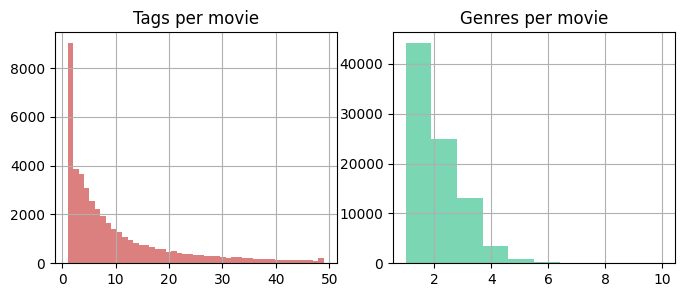

In [4]:
import matplotlib.pyplot as plt

tags_grouped["tag_count"] = tags_grouped["tag"].str.split().str.len()
movieTags = movieDF.merge(tags_grouped, on="movieId", how="left")

movieDF["genre_count"] = movieDF["genres"].str.split("|").str.len()

fig, ax = plt.subplots(1, 2, figsize=(8, 3))

movieTags[movieTags["tag_count"] < 50]["tag_count"].hist(bins=47, ax=ax[0], color="#DB7F7F")
movieDF["genre_count"].hist(bins=10, ax=ax[1], color="#7AD6B3")

ax[0].set_title("Tags per movie")
ax[1].set_title("Genres per movie")



In [ ]:
movieDF["genre_count"].describe()

count    86537.000000
mean         1.759802
std          0.944122
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: genre_count, dtype: float64

In [ ]:
movieTags["tag_count"].describe()

count    53452.000000
mean        72.340062
std        320.244235
min          1.000000
25%          4.000000
50%          9.000000
75%         28.000000
max      19358.000000
Name: tag_count, dtype: float64

#### Observationer
För att kunna skapa användbara tf-idf vektorer är det relevant att kolla kvantitet och kvalitet på den deskriptiva information vi har om filmerna. Den information som kan användas är filmens titel, årtal, genre och tag-ord. Tagsdatasetet innehåller 53452 unika filmer och moviedatasetet innehåller 86537 filmer. Detta innebär att 33085 filmer helt saknar tag-ord. Samtliga filmer har dock minst en genre och endast 618 filmer saknar årtal. 
I ratingsdatasetet finns 83239 unika filmer vilket innebär att 3298 filmer saknar betyg. 50% av filmerna har 5 eller fler omdömmen. 

In [ ]:
from recommender import load_data
movies, ratings, movieTags2, tfidf = load_data(moviePath="movieDF.pkl", ratingsPath="ratingsDF.pkl", movieTagsPath="movieTags.pkl")

In [ ]:
movieTags2["word_count"] = movieTags2["text"].str.split().str.len()

movieTags2["word_count"].describe()

count    86537.000000
mean        50.960006
std        254.246591
min          2.000000
25%          6.000000
50%         10.000000
75%         19.000000
max      19370.000000
Name: word_count, dtype: float64

In [ ]:
ratings.groupby("movieId").size().describe()

count     83239.000000
mean        406.446041
std        2806.975876
min           1.000000
25%           2.000000
50%           5.000000
75%          26.000000
max      122296.000000
dtype: float64

In [ ]:
movieTags2[movieTags2["year"] == ""].shape

(618, 9)

#### Data behandling

I filen prepare_data.py finns ett script som förbereder datan.
Titlarna behöver vara sökbara. De formateras därför om till ett format som gör de enklare att hitta i sökfunktionen. Årtal separeras från titeln och flyttas till en egen kolumn. Undantaget är de filmer som delar samma titel. Där inkluderas årtalet för att de skall kunna skiljas åt. Filmer som börjar med "The" kräver särskilld hantering då de står i formatet "filmtitel, The", vilket gör dem svåra att hitta. 

Den textsträng som skall används för tf-idf matrisen formas genom att slå ihop de kolumner som innehåller beskrivande information om filmen. 
Bedömningen görs att specifika årtal inte är relevanta att inkludera i textsträngen. Däremot kan tidseran säga något om filmens karraktär. Därför kategoriseras filmerna efter decenium i en kolumn för att sedan inkluderas i textsträngen. 

Nan-värden hanteras genom att fyllas i med tom sträng. 
De bearbetade dataseten sparas i pickle-format för att de snabbt skall kunna läsas in till modellen. 

### Modell

Modellen är en hybrid som består av en content-based del och en colaborative-filtering del.
I den första content baserade delen används tf-idf vektorisering och cosinuslikhet för att rangordna filmerna efter likhet till den angivna filmen. En viss bestämd mängd av de mest lika filmerna används därefter i collaborative-filtering delen. 
Eftersom det bara finns en given filmtitel och ingen information om användaren är enda alternativet att använda item-based collaborative filtering vilket innebär att filmernas likhet avgörs av hur de har betygsats av användare. 
Denna del använder cosinuslikhet för att rangordna filmerna och de 5 filmer som är mest lika den angivna filmen returneras. 
Detta upplägg grundar sig främst i att ratingsdatan är för stor för att hanteras i sin helhet. Den här modellen tillåter att endast en mindre del av datasetet behöver användas. 

#### Hyperparametrar
För Tf-idf vektoriseringen används följande hyperparametrar:
- stop_words="english"
- ngram_range=(1, 3)
- min_df= 4
- sublinear_tf=True

Majoriteten av taggarna består av ett eller två ord och ett fåtal av 3 ord. ngram sätts till (1, 3) för att fånga upp samtliga.

I modellen finns också parametern Top_n som är antalet filmer som tas ut av del 1. Den kan användas för att ge större eller mindre vikt åt vardera del. Om ett stort antal hämtas läggs mer vikt på användarbetygen och ett mindre antal innebär mer vikt på semantisk likhet. I detta fall har värdet top_n= 200 använts.   


### Resultat
![Resultat för "The illusionist"](recommender.png)

In [ ]:
from recommender import hybrid_recommender

testMovies = ["finding nemo", "citizen kane", "inception", "edward scissorhands", "the holiday", "the room (2003)"]

results = {}
for movie in testMovies:
    recs = hybrid_recommender(movie, tfidf ,movies, ratings, movieTags2, top_n=200)
    results[movie] = recs

resultsDF = pd.DataFrame(results)
resultsDF.head()

,finding nemo,citizen kane,inception,edward scissorhands,the holiday,the room (2003)
0,Shrek,Dr. Strangelove or: How I Learned to Stop Worr...,The Dark Knight (2008),The Nightmare Before Christmas,How to Lose a Guy in 10 Days,They Live
1,"Monsters, Inc.",Vertigo,Inglourious Basterds,The Truman Show,Love Actually,Manos: The Hands of Fate
2,Shrek 2,Casablanca,Shutter Island,Beetlejuice,27 Dresses,Birdemic: Shock and Terror
3,The Incredibles,Psycho (1960),The Dark Knight Rises,Being John Malkovich,He's Just Not That Into You,Samurai Cop
4,Ratatouille,Chinatown,Interstellar,Sleepy Hollow,The Proposal (2009),Fateful Findings


### Diskission 

Att utvärdera resultatets relevans är högst subjektivt och det är svårt att utgå ifrån konkreta mått. Enligt Géron 2025 kan man bevaka en rekommendationsalgorithm på en hemsida och se hur många sälj det resulterar i. I fallet med filmer skulle det kunna innebära att man ser hur ofta användare klickar och kollar på de rekommenderade filmerna. Detta är inte möjligt i det här fallet. Om premissen att imdb ger relvanta rekommendationer accepteras kan en jämförelse göras. På det urval av filmer som testades kan ett överlapp med imdbs rekommendationer observeras, vilket kan ge en liten indikation på att resultatet är relevant.

Det kan också konstateras att modellen ger ofta bättre resultat på mer kända och populära filmer och sämmre på mer okända filmer. Detta kan bero på att dessa filmer har både mer taggar och fler användaromdömmen att utgå ifrån. I några fall ger modellen sämre resultat på toprankade filmer. Detta kan bero på en obalans i antalet tag-ord. 75% av filmerna innehåller 19 eller färre ord i sin beskrivande textsträng medan några outliers innehåller upp emot 20000. Dessa filmer med extremt många tag-ord, som i vissa fall sammanfaller med populära filmer, tenderar ofta att  rekommendera varandra, trots att de inte nödvändigtvis delar uppenbar semantisk likhet. Ett exempel är "Forrest Gump" och "När lammen tystnar" som dyker upp i varandras rekommendationer trots att de till stor del är semantiskt olika. Dessa två filmer har båda över 6000 tag-ord. Det går till viss del att komma runt detta genom att justera top_n parametern, dock leder detta oftast bara till bättre resultat endast på dessa filmer medans många andra får sämmre resultat. En möjlig förbättring skulle kunna vara att sätta en max gräns på antalet taggar och minska antalet på de filmer som har för många.    

Användnigen av TF-IDF för att jämföra likheten mellan filmerna fungerar i praktiken men metoden har begränsningar. Den baseras endast på förkomsten av ord utan hänsyn till deras semantiska betydelse.
Användning av embedings skulle kunna förbättra resultatet. Andra mer avanserade metoder som SBERT är bra på att förstå semantik men behöver hela meningar eller stycken för att vara användbar. Det skulle kunna vara ett alternativ om  filmernas handling eller recensioner användes.

sammanfattningsvis visar resultaten att hybridmodellen är effektiv men att kvaletén till stor del beror på tillgången och balansen i underliggande data.  




### Källor

Aurélien Géron, (2025), *Hands on machine learning with sci-kit learn and PyTorch*
